In [1]:
# Colab dependencies
!pip install -q datasets transformers accelerate scikit-learn seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = pd.DataFrame(ds["train"])
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [4]:
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

In [5]:
train_idx = np.loadtxt("train_idx.txt", dtype=int)
val_idx = np.loadtxt("val_idx.txt", dtype=int)
test_idx = np.loadtxt("test_idx.txt", dtype=int)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

49412 6176 6177


##EDA

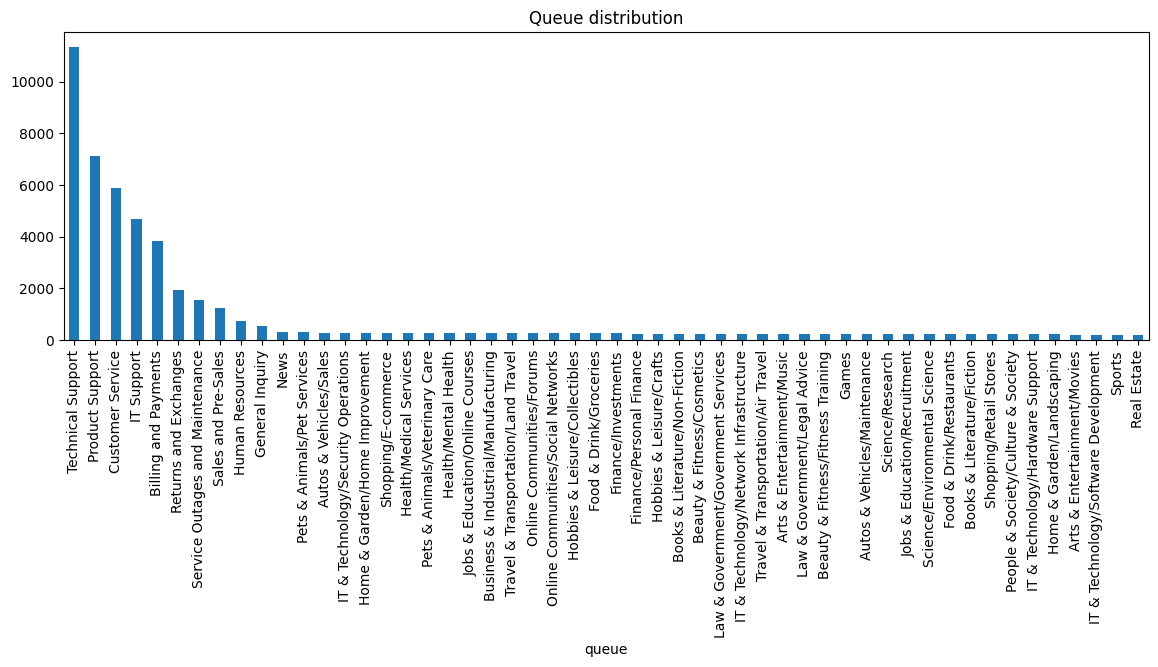

In [6]:
plt.figure(figsize=(14,4))

train_df["queue"].value_counts().plot(kind="bar")

plt.title("Queue distribution")
plt.show()

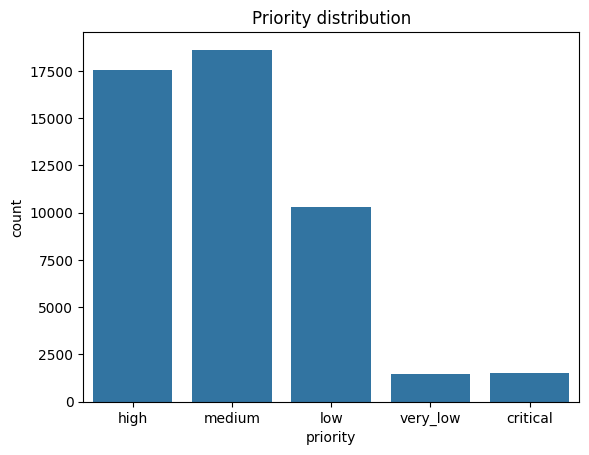

In [7]:
sns.countplot(x=train_df["priority"])
plt.title("Priority distribution")
plt.show()

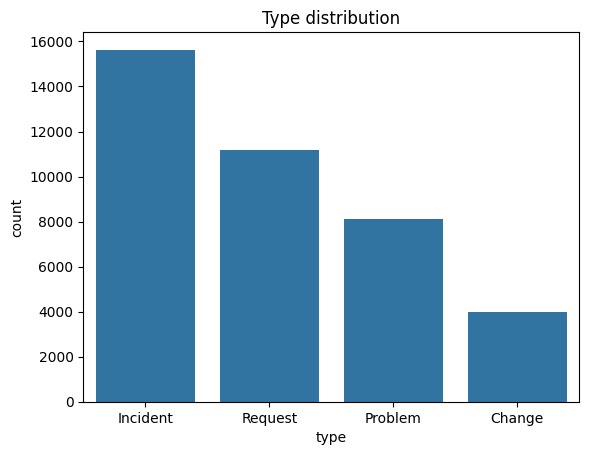

In [8]:
sns.countplot(x=train_df["type"])
plt.title("Type distribution")
plt.show()

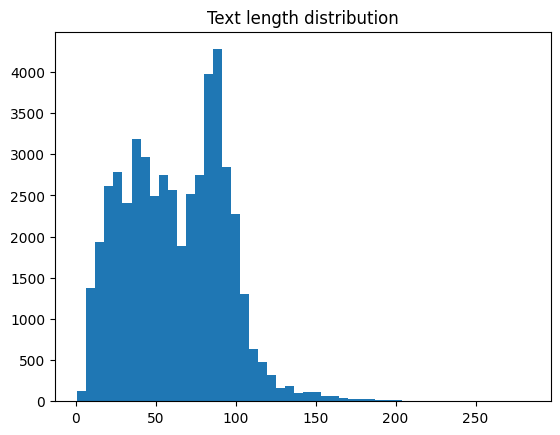

In [9]:
train_df["length"] = train_df["text"].apply(lambda x: len(x.split()))

plt.hist(train_df["length"], bins=50)
plt.title("Text length distribution")
plt.show()

##Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

queue_enc = LabelEncoder()
priority_enc = LabelEncoder()
type_enc = LabelEncoder()

train_df["queue_id"] = queue_enc.fit_transform(train_df["queue"])
val_df["queue_id"] = queue_enc.transform(val_df["queue"])
test_df["queue_id"] = queue_enc.transform(test_df["queue"])

train_df["priority_id"] = priority_enc.fit_transform(train_df["priority"])
val_df["priority_id"] = priority_enc.transform(val_df["priority"])
test_df["priority_id"] = priority_enc.transform(test_df["priority"])

train_df["type_id"] = type_enc.fit_transform(train_df["type"])
val_df["type_id"] = type_enc.transform(val_df["type"])
test_df["type_id"] = type_enc.transform(test_df["type"])

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

##Baseline: TF-IDF + logistic regression

In [12]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("clf", LogisticRegression(max_iter=200))
])

In [13]:
pipe.fit(train_df["text"], train_df["queue_id"])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=50000)),
                ('clf', LogisticRegression(max_iter=200))])

In [15]:
pipe_queue = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("clf", LogisticRegression(max_iter=200))
])

pipe_queue.fit(train_df["text"], train_df["queue_id"])

queue_pred = pipe_queue.predict(test_df["text"])

queue_macro_f1 = f1_score(
    test_df["queue_id"],
    queue_pred,
    average="macro"
)

queue_acc = accuracy_score(
    test_df["queue_id"],
    queue_pred
)

print("Queue Macro-F1:", queue_macro_f1)
print("Queue Accuracy:", queue_acc)

Queue Macro-F1: 0.7736314470032354
Queue Accuracy: 0.5462198478225676


In [16]:
pipe_priority = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("clf", LogisticRegression(max_iter=200))
])

pipe_priority.fit(train_df["text"], train_df["priority_id"])

priority_pred = pipe_priority.predict(test_df["text"])

acc_priority = accuracy_score(
    test_df["priority_id"],
    priority_pred
)

print("Priority Accuracy:", acc_priority)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Priority Accuracy: 0.5986724947385462


In [17]:
pipe_type = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("clf", LogisticRegression(max_iter=200))
])

pipe_type.fit(train_df["text"], train_df["type_id"])

type_pred = pipe_type.predict(test_df["text"])

acc_type = accuracy_score(
    test_df["type_id"],
    type_pred
)

print("Type Accuracy:", acc_type)

Type Accuracy: 0.8589930386919217


In [18]:
baseline_score = (
    0.70 * queue_macro_f1
    + 0.15 * acc_priority
    + 0.15 * acc_type
)

print("\n=== TF-IDF BASELINE FINAL SCORE ===")
print("Score:", baseline_score)


=== TF-IDF BASELINE FINAL SCORE ===
Score: 0.7601918429168351


#Val metrics

In [19]:
pred = pipe.predict(val_df["text"])

macro_f1 = f1_score(val_df["queue_id"], pred, average="macro")
acc = accuracy_score(val_df["queue_id"], pred)

print("Baseline Queue Macro-F1:", macro_f1)
print("Baseline Queue Accuracy:", acc)

Baseline Queue Macro-F1: 0.7896783201426144
Baseline Queue Accuracy: 0.5566709844559585


In [20]:
from transformers import AutoTokenizer
from transformers import AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

##Transformer model

In [21]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [22]:
class TicketDataset(Dataset):

    def __init__(self, df):

        self.texts = df["text"].tolist()

        self.queue = df["queue_id"].values
        self.priority = df["priority_id"].values
        self.type = df["type_id"].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        item = {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "queue": torch.tensor(self.queue[idx]),
            "priority": torch.tensor(self.priority[idx]),
            "type": torch.tensor(self.type[idx]),
        }

        return item

In [23]:
train_dataset = TicketDataset(train_df)
val_dataset = TicketDataset(val_df)
test_dataset = TicketDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [24]:
class MultiTaskBERT(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL_NAME)

        hidden = self.encoder.config.hidden_size

        self.queue_head = nn.Linear(hidden, len(queue_enc.classes_))
        self.priority_head = nn.Linear(hidden, len(priority_enc.classes_))
        self.type_head = nn.Linear(hidden, len(type_enc.classes_))

    def forward(self, input_ids, attention_mask):

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = out.last_hidden_state[:,0]

        queue = self.queue_head(cls)
        priority = self.priority_head(cls)
        type_ = self.type_head(cls)

        return queue, priority, type_

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiTaskBERT().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

loss_fn = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
EPOCHS = 3

#Training

In [29]:
for epoch in range(EPOCHS):

    model.train()

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        q = batch["queue"].to(device)
        p = batch["priority"].to(device)
        t = batch["type"].to(device)

        optimizer.zero_grad()

        q_logits, p_logits, t_logits = model(input_ids, mask)

        loss_q = loss_fn(q_logits, q)
        loss_p = loss_fn(p_logits, p)
        loss_t = loss_fn(t_logits, t)

        loss = loss_q + 0.5 * loss_p + 0.5 * loss_t

        loss.backward()
        optimizer.step()

    print("epoch", epoch, "loss", loss.item())

epoch 0 loss 1.8962571620941162
epoch 1 loss 1.0568686723709106
epoch 2 loss 2.2626571655273438


#EVAL

In [30]:
model.eval()

queue_preds = []
queue_true = []

priority_preds = []
priority_true = []

type_preds = []
type_true = []

confidences = []

In [31]:
with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        q_logits, p_logits, t_logits = model(input_ids, mask)

        q_probs = torch.softmax(q_logits, dim=1)

        conf = q_probs.max(dim=1).values

        confidences.extend(conf.cpu().numpy())

        queue_preds.extend(q_logits.argmax(1).cpu().numpy())
        queue_true.extend(batch["queue"].numpy())

        priority_preds.extend(p_logits.argmax(1).cpu().numpy())
        priority_true.extend(batch["priority"].numpy())

        type_preds.extend(t_logits.argmax(1).cpu().numpy())
        type_true.extend(batch["type"].numpy())

Metrics

In [32]:
macro_f1_queue = f1_score(queue_true, queue_preds, average="macro")

acc_queue = accuracy_score(queue_true, queue_preds)
acc_priority = accuracy_score(priority_true, priority_preds)
acc_type = accuracy_score(type_true, type_preds)

print("Macro-F1 Queue:", macro_f1_queue)
print("Acc Queue:", acc_queue)
print("Acc Priority:", acc_priority)
print("Acc Type:", acc_type)

Macro-F1 Queue: 0.8591243841033107
Acc Queue: 0.6125951108952566
Acc Priority: 0.6009389671361502
Acc Type: 0.859478711348551


#Final score

In [33]:
score = (
    0.70 * macro_f1_queue
    + 0.15 * acc_priority
    + 0.15 * acc_type
)

print("FINAL SCORE:", score)

FINAL SCORE: 0.8204497206450225


In [34]:
confidences = np.array(confidences)
queue_preds = np.array(queue_preds)
queue_true = np.array(queue_true)

In [35]:
def evaluate_coverage(percent):

    threshold = np.quantile(confidences, 1-percent)

    mask = confidences >= threshold

    f1 = f1_score(queue_true[mask], queue_preds[mask], average="macro")

    return f1

In [36]:
coverages = [1.0,0.9,0.8,0.7,0.6]

for c in coverages:

    f1 = evaluate_coverage(c)

    print(c, "coverage F1:", f1)

1.0 coverage F1: 0.8591243841033107
0.9 coverage F1: 0.8698175905196224
0.8 coverage F1: 0.8833866343045339
0.7 coverage F1: 0.895432724765237
0.6 coverage F1: 0.9072944561837981


In [37]:
errors = test_df.copy()

errors["pred_queue"] = queue_enc.inverse_transform(queue_preds)

errors = errors[errors["queue"] != errors["pred_queue"]]

errors[["text","queue","pred_queue"]].head(10)

,text,queue,pred_queue
1,Organizational Revision Dear Customer Support ...,General Inquiry,Customer Service
2,Mängel im Incident-Response-Prozess Sehr geehr...,IT Support,Business & Industrial/Manufacturing
4,Occasional Disruptions Across Several Products...,IT Support,Technical Support
5,Anfrage zu Investment-Strategie-Angeboten Sehr...,Product Support,Customer Service
10,"Synchronization Problem Dear Customer Support,...",IT Support,Product Support
14,Peripheral Device Problems Dear Customer Suppo...,Human Resources,Technical Support
15,Improving Agile Microservices Processes Dear C...,General Inquiry,IT Support
17,"Problem Dear Customer Support Team,\n\nI hope ...",IT Support,Product Support
19,Query About Compatibility of Integration Dear ...,Technical Support,Customer Service
21,Immediate Attention Needed: Peripheral Softwar...,IT Support,Technical Support
